In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df_full = pd.read_csv('mpi_roof.csv')
df_full['Date Time'] = pd.to_datetime(df_full['Date Time'])
df_full.set_index('Date Time', inplace=True)

print(f"\nРазмер выборки: {df_full.shape[0]} строк, {df_full.shape[1]} столбцов")
print("\nПризнаки:")
for col in df_full.columns:
    print(f"  - {col}")
print("\nПервые 5 строк:")
print(df_full.head())


Размер выборки: 1051920 строк, 20 столбцов

Признаки:
  - p (mbar)
  - T (degC)
  - Tpot (K)
  - Tdew (degC)
  - rh (%)
  - VPmax (mbar)
  - VPact (mbar)
  - VPdef (mbar)
  - sh (g/kg)
  - H2OC (mmol/mol)
  - rho (g/m**3)
  - wv (m/s)
  - max. wv (m/s)
  - wd (deg)
  - rain (mm)
  - raining (s)
  - SWDR (W/m²)
  - PAR (µmol/m²/s)
  - max. PAR (µmol/m²/s)
  - Tlog (degC)

Первые 5 строк:
                     p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
Date Time                                                                
2004-01-01 00:10:00    996.82     -0.84    272.57        -1.23    97.2   
2004-01-01 00:20:00    996.69     -0.78    272.64        -1.22    96.8   
2004-01-01 00:30:00    996.69     -0.77    272.64        -1.29    96.3   
2004-01-01 00:40:00    996.67     -0.77    272.65        -1.39    95.6   
2004-01-01 00:50:00    996.52     -0.77    272.66        -1.44    95.2   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time     

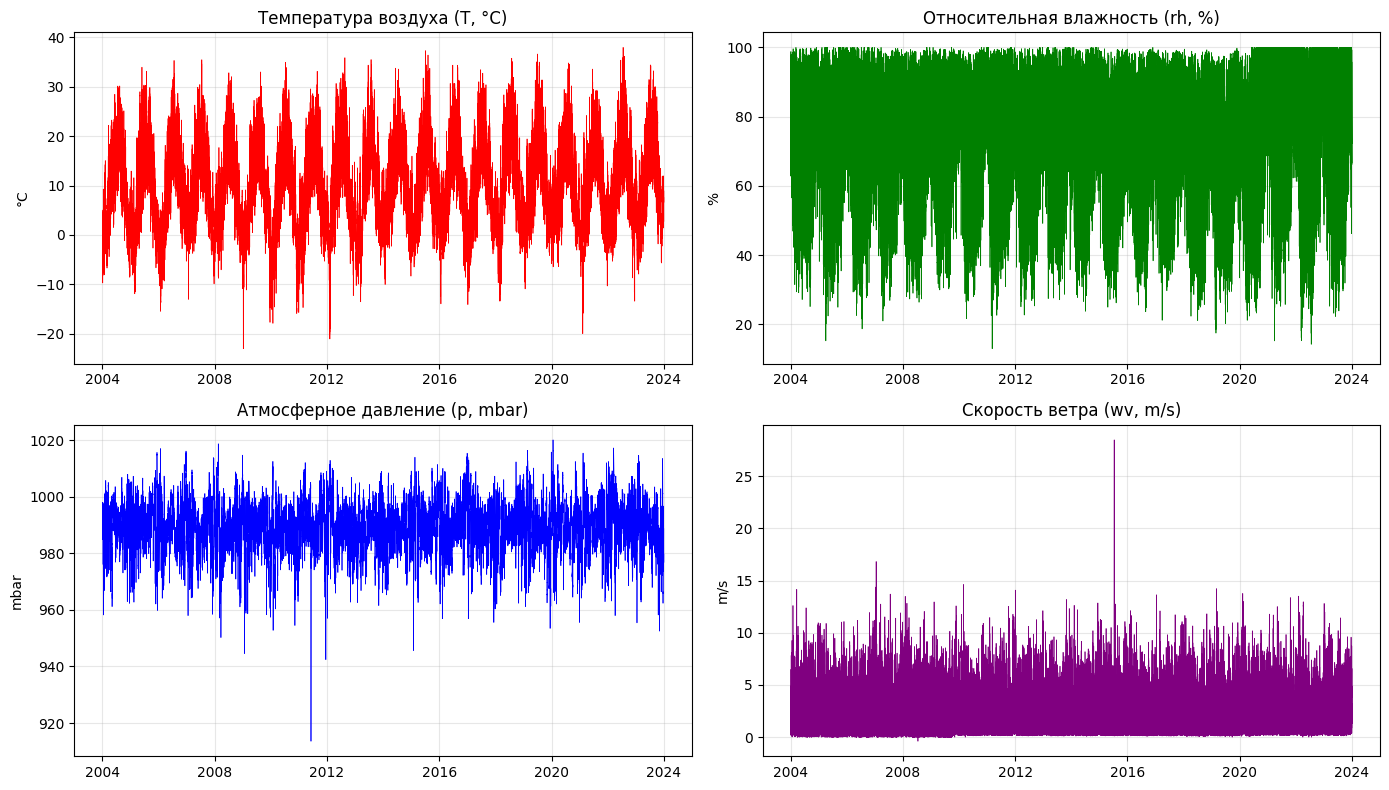

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(df_full.index, df_full['T (degC)'], color='red', linewidth=0.5)
axes[0,0].set_title('Температура воздуха (T, °C)')
axes[0,0].set_ylabel('°C')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(df_full.index, df_full['rh (%)'], color='green', linewidth=0.5)
axes[0,1].set_title('Относительная влажность (rh, %)')
axes[0,1].set_ylabel('%')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(df_full.index, df_full['p (mbar)'], color='blue', linewidth=0.5)
axes[1,0].set_title('Атмосферное давление (p, mbar)')
axes[1,0].set_ylabel('mbar')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(df_full.index, df_full['wv (m/s)'], color='purple', linewidth=0.5)
axes[1,1].set_title('Скорость ветра (wv, m/s)')
axes[1,1].set_ylabel('m/s')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
#ПРОВЕРКА СТАЦИОНАРНОСТИ
# Для ускорения беру каждый 100-й элемент
df_sample = df_full.iloc[::100]

def check_stationarity(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    is_stationary = result[1] <= 0.05
    status = "СТАЦИОНАРНЫЙ" if is_stationary else "НЕСТАЦИОНАРНЫЙ"
    print(f"{name:20} | p-value: {result[1]:.6f} | {status}")
    return is_stationary

for col in ['T (degC)', 'rh (%)', 'p (mbar)', 'wv (m/s)']:
    check_stationarity(df_sample[col], col)

T (degC)             | p-value: 0.000002 | СТАЦИОНАРНЫЙ
rh (%)               | p-value: 0.000000 | СТАЦИОНАРНЫЙ
p (mbar)             | p-value: 0.000000 | СТАЦИОНАРНЫЙ
wv (m/s)             | p-value: 0.000000 | СТАЦИОНАРНЫЙ


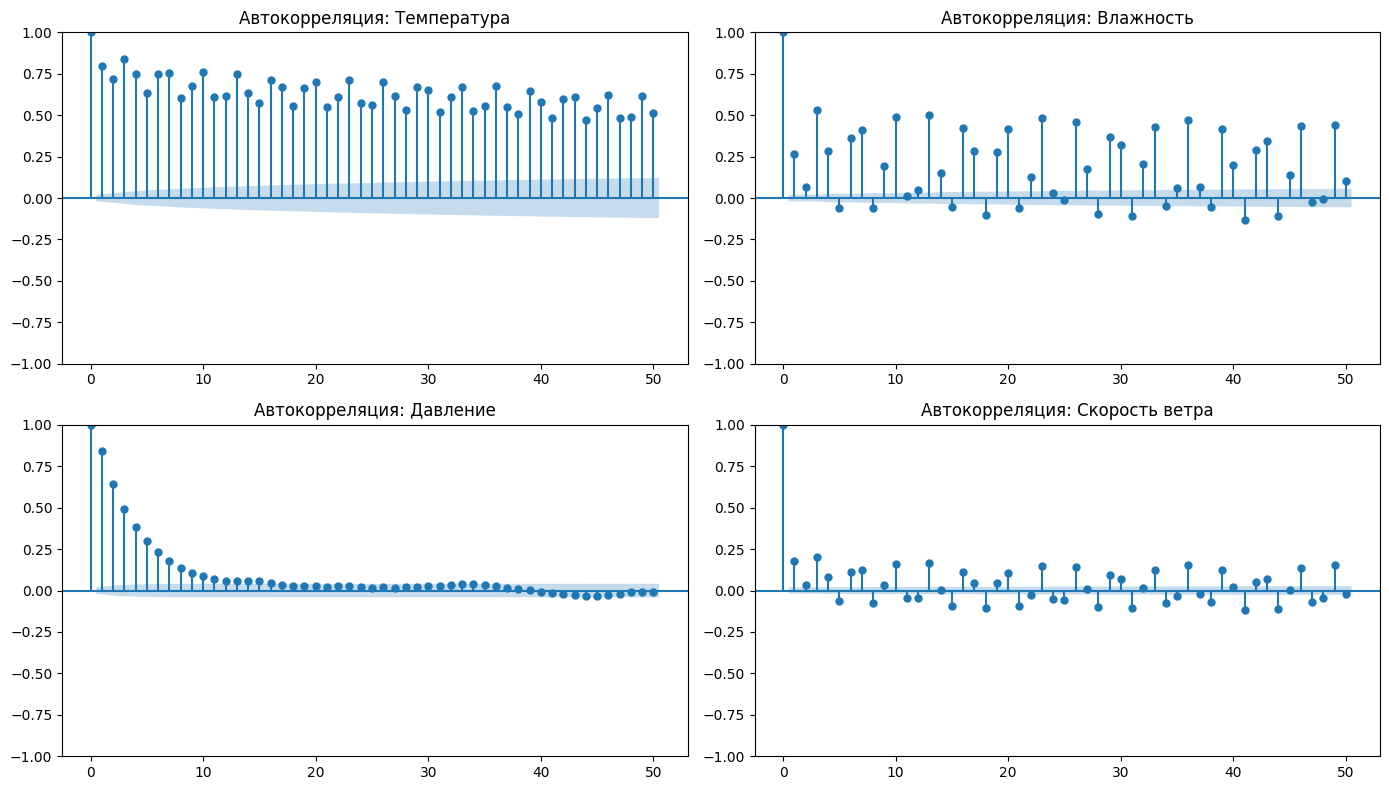

In [8]:
# Анализ автокорреляции 
df_sample = df_full.iloc[::100]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df_sample['T (degC)'].dropna(), lags=50, ax=axes[0,0], alpha=0.05)
axes[0,0].set_title('Автокорреляция: Температура')

plot_acf(df_sample['rh (%)'].dropna(), lags=50, ax=axes[0,1], alpha=0.05)
axes[0,1].set_title('Автокорреляция: Влажность')

plot_acf(df_sample['p (mbar)'].dropna(), lags=50, ax=axes[1,0], alpha=0.05)
axes[1,0].set_title('Автокорреляция: Давление')

plot_acf(df_sample['wv (m/s)'].dropna(), lags=50, ax=axes[1,1], alpha=0.05)
axes[1,1].set_title('Автокорреляция: Скорость ветра')

plt.tight_layout()
plt.show()

In [9]:
# Предобработка 
# Беру первые 10000 строк для обучения
df = df_full.head(10000)

target = 'T (degC)'
features = ['p (mbar)', 'rh (%)', 'wv (m/s)', 'SWDR (W/m²)']

df_model = df[features + [target]].copy()

print(f"\nПропуски до обработки:\n{df_model.isnull().sum()}")

# Интерполяция
df_model = df_model.interpolate(method='linear')

# Обработка выбросов
print("\nОбработка выбросов:")
for col in df_model.columns:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    print(f"  {col}: {outliers} выбросов")
    df_model[col] = df_model[col].clip(lower, upper)

print(f"\nПропуски после обработки: {df_model.isnull().sum().sum()}")


Пропуски до обработки:
p (mbar)       0
rh (%)         0
wv (m/s)       0
SWDR (W/m²)    0
T (degC)       0
dtype: int64

Обработка выбросов:
  p (mbar): 0 выбросов
  rh (%): 73 выбросов
  wv (m/s): 244 выбросов
  SWDR (W/m²): 1324 выбросов
  T (degC): 569 выбросов

Пропуски после обработки: 0


In [11]:
# Извлечение признаков

df_features = df_model.copy()

# Метод 1: Lag features
df_features['T_lag1'] = df_features[target].shift(1)
df_features['T_lag6'] = df_features[target].shift(6)
df_features['T_lag12'] = df_features[target].shift(12)

# Метод 2: Rolling statistics
df_features['T_rolling_mean_6'] = df_features[target].rolling(window=6).mean()
df_features['T_rolling_mean_12'] = df_features[target].rolling(window=12).mean()
df_features['T_rolling_std_6'] = df_features[target].rolling(window=6).std()

# Метод 3: Статистические признаки
df_features['T_mean'] = df_features[target].mean()
df_features['T_std'] = df_features[target].std()
df_features['T_min'] = df_features[target].min()
df_features['T_max'] = df_features[target].max()
df_features['T_range'] = df_features['T_max'] - df_features['T_min']

df_features = df_features.dropna()
print(f"\nИтоговое количество строк: {df_features.shape[0]}")
print(f"Итоговое количество признаков: {df_features.shape[1]}")


Итоговое количество строк: 9988
Итоговое количество признаков: 16


In [ ]:
# Подготовка данных для обучения

feature_cols = ['p (mbar)', 'rh (%)', 'wv (m/s)', 'SWDR (W/m²)',
                'T_lag1', 'T_lag6', 'T_lag12',
                'T_rolling_mean_6', 'T_rolling_mean_12', 'T_rolling_std_6',
                'T_mean', 'T_std', 'T_min', 'T_max', 'T_range']

X = df_features[feature_cols].values
y = df_features[target].values

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Разделение на train/test 
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} строк")
print(f"Test: {X_test.shape[0]} строк")

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер X: (9988, 15)
Размер y: (9988,)
Train: 7990 строк
Test: 1998 строк


In [28]:
# Модель 1 - Random Forest

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("Модель обучена")

y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
r2_rf = r2_score(y_test, y_test_pred_rf)

print(f"\nРезультаты Random Forest:")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.4f}")
print(f"Test RMSE: {rmse_rf:.4f}")
print(f"Test MAE:  {mae_rf:.4f}")
print(f"Test R2:   {r2_rf:.4f}")

Модель обучена

Результаты Random Forest:
Train RMSE: 0.0609
Test RMSE: 0.1516
Test MAE:  0.1038
Test R2:   0.9961


In [15]:
# Подготовка данных для LSTM/GRU
def create_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

SEQ_LENGTH = 12
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, SEQ_LENGTH)

print(f"Данные для LSTM/GRU: {X_train_seq.shape}")

Данные для LSTM/GRU: (7978, 12, 15)


In [29]:
# Модель 2 - LSTM

lstm_model = Sequential([
    LSTM(32, input_shape=(SEQ_LENGTH, X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, 
               validation_split=0.1, callbacks=[early_stop], verbose=1)

y_test_pred_lstm = lstm_model.predict(X_test_seq).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_test_pred_lstm))
mae_lstm = mean_absolute_error(y_test_seq, y_test_pred_lstm)
r2_lstm = r2_score(y_test_seq, y_test_pred_lstm)

print(f"\nРезультаты LSTM:")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAE:  {mae_lstm:.4f}")
print(f"R2:   {r2_lstm:.4f}")

Epoch 1/30


c:\Users\polik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 7.7899 - val_loss: 0.7037
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9764 - val_loss: 0.3110
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5614 - val_loss: 0.2839
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4627 - val_loss: 0.1907
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4174 - val_loss: 0.1849
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3957 - val_loss: 0.1620
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3737 - val_loss: 0.1460
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3626 - val_loss: 0.1299
Epoch 9/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3657 - val_loss: 0.1165
Epoch 10/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3465 - val_loss: 0.1166
Epoch 11/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3356 - val_loss: 0.1031
Epoch 12/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 

In [30]:
# Модель 3 - GRU

gru_model = Sequential([
    GRU(32, input_shape=(SEQ_LENGTH, X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=1)

y_test_pred_gru = gru_model.predict(X_test_seq).flatten()

rmse_gru = np.sqrt(mean_squared_error(y_test_seq, y_test_pred_gru))
mae_gru = mean_absolute_error(y_test_seq, y_test_pred_gru)
r2_gru = r2_score(y_test_seq, y_test_pred_gru)

print(f"\nРезультаты GRU:")
print(f"RMSE: {rmse_gru:.4f}")
print(f"MAE:  {mae_gru:.4f}")
print(f"R2:   {r2_gru:.4f}")

Epoch 1/30


c:\Users\polik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 3.8433 - val_loss: 0.2702
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5514 - val_loss: 0.1598
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4350 - val_loss: 0.1288
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3994 - val_loss: 0.1393
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3725 - val_loss: 0.0946
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Результаты GRU:
RMSE: 0.4080
MAE:  0.3040
R2:   0.9716


In [23]:
# Сравнение моделей
comparison = pd.DataFrame({
    'Модель': ['Random Forest', 'LSTM', 'GRU'],
    'RMSE': [rmse_rf, rmse_lstm, rmse_gru],
    'MAE': [mae_rf, mae_lstm, mae_gru],
    'R2': [r2_rf, r2_lstm, r2_gru]
})

print(comparison.to_string(index=False))

best = comparison.loc[comparison['RMSE'].idxmin(), 'Модель']
print(f"ЛУЧШАЯ МОДЕЛЬ: {best}")

       Модель     RMSE      MAE       R2
Random Forest 0.151584 0.103795 0.996085
         LSTM 0.232342 0.174660 0.990791
          GRU 0.555686 0.432469 0.947325
ЛУЧШАЯ МОДЕЛЬ: Random Forest


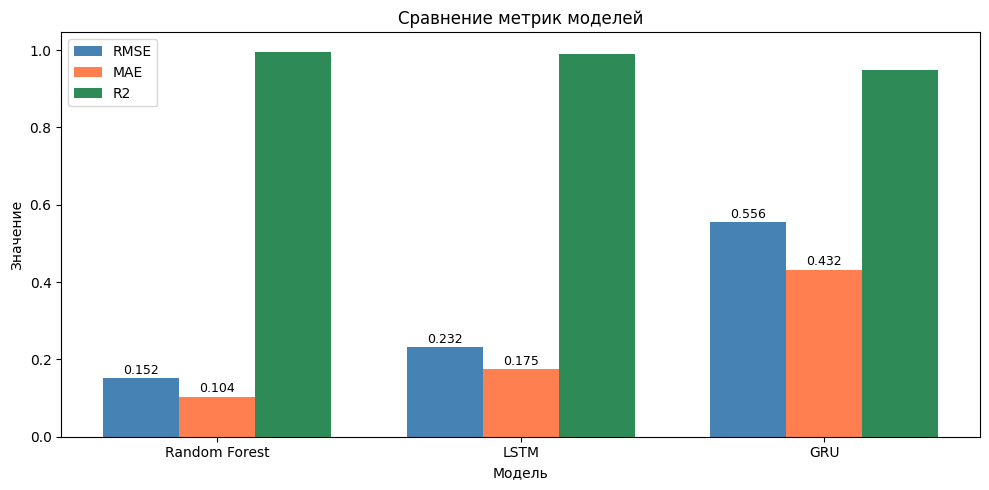

In [25]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(comparison))
width = 0.25

bars1 = ax.bar([i - width for i in x], comparison['RMSE'], width, label='RMSE', color='steelblue')
bars2 = ax.bar(x, comparison['MAE'], width, label='MAE', color='coral')
bars3 = ax.bar([i + width for i in x], comparison['R2'], width, label='R2', color='seagreen')

ax.set_xlabel('Модель')
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик моделей')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Модель'])
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

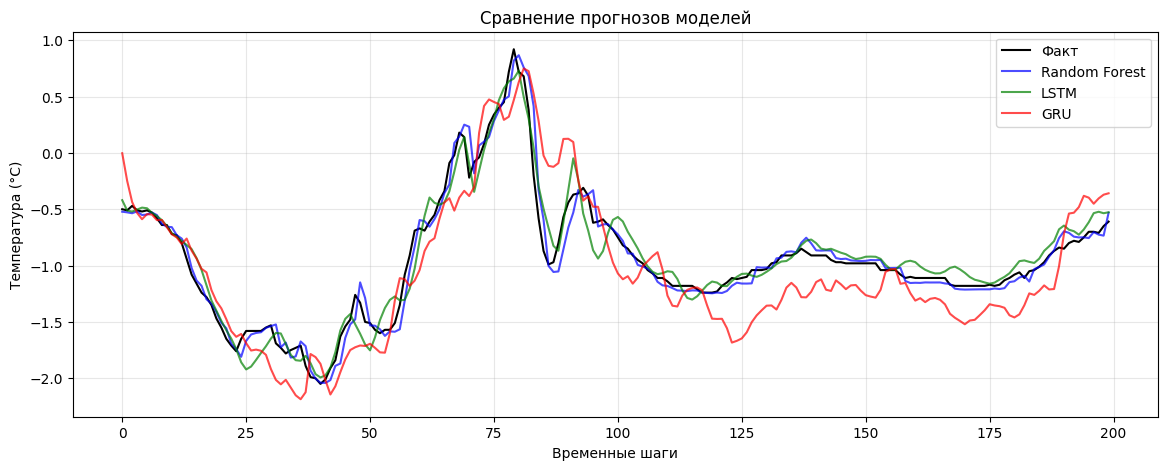

In [27]:
# График прогнозов
fig, ax = plt.subplots(figsize=(14, 5))

n = min(200, len(y_test))
ax.plot(y_test[-n:], label='Факт', color='black', linewidth=1.5)
ax.plot(y_test_pred_rf[-n:], label='Random Forest', color='blue', alpha=0.7)
ax.plot(y_test_pred_lstm[-n:], label='LSTM', color='green', alpha=0.7)
ax.plot(y_test_pred_gru[-n:], label='GRU', color='red', alpha=0.7)

ax.set_title('Сравнение прогнозов моделей')
ax.set_xlabel('Временные шаги')
ax.set_ylabel('Температура (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()